In [440]:
import pandas as pd


df = pd.read_csv('dhaka homeprices.csv')
df.head()

,area,price
0,2600,55000
1,3000,56500
2,3200,61000
3,3600,68000
4,4000,72000


In [441]:
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (10, 2)
Is Null Any: 
area     False
price    False
dtype: bool
Is Null Sum: 
area     0
price    0
dtype: int64


In [442]:
# Assign X and y
X = df[["area"]]
y = df["price"]

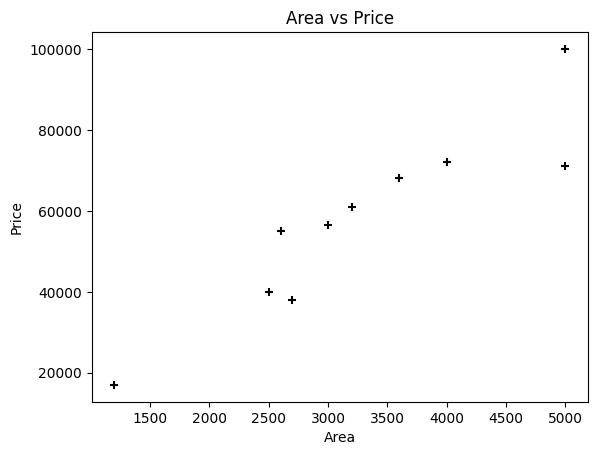

In [443]:
# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X, y, marker="+", color="black")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [444]:
# Split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Print the shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8, 1)
X_test shape: (2, 1)
y_train shape: (8,)
y_test shape: (2,)


In [445]:
# Linear regression model
from sklearn.linear_model import LinearRegression


model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [446]:
# Print the report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"R2 score: {r2_score(y_test, model.predict(X_test))}")
print(f"Mean absolute error: {mean_absolute_error(y_test, model.predict(X_test))}")
print(f"Mean squared error: {mean_squared_error(y_test, model.predict(X_test))}")

R2 score: 0.5040430697798004
Mean absolute error: 12522.91551628934
Mean squared error: 188587622.71623093


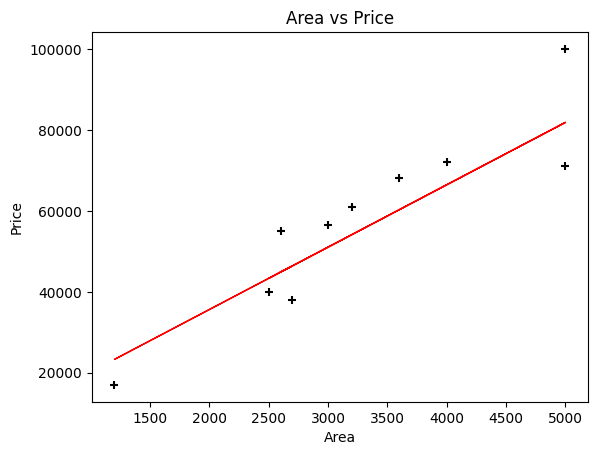

In [447]:
# Plot the model prediction
plt.scatter(X, y, marker="+", color="black")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.plot(X, model.predict(X), color="red", linewidth=1)
plt.show()

In [448]:
# Print the coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients: [15.40447267]
Intercept: 4818.746548868017


In [449]:
# Linear regression model with multiple y inputs
df = pd.read_csv("hiring.csv")
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [450]:
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (8, 4)
Is Null Any: 
experience                     True
test_score(out of 10)          True
interview_score(out of 10)    False
salary($)                     False
dtype: bool
Is Null Sum: 
experience                    2
test_score(out of 10)         1
interview_score(out of 10)    0
salary($)                     0
dtype: int64


In [451]:
# Fill the NaN values
df["experience"] = df["experience"].fillna("zero")
df["test_score(out of 10)"] = df["test_score(out of 10)"].fillna(df["test_score(out of 10)"].mean())
df["interview_score(out of 10)"] = df["interview_score(out of 10)"].fillna(df["interview_score(out of 10)"].mean())
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Is Null Any: 
experience                    False
test_score(out of 10)         False
interview_score(out of 10)    False
salary($)                     False
dtype: bool
Is Null Sum: 
experience                    0
test_score(out of 10)         0
interview_score(out of 10)    0
salary($)                     0
dtype: int64


In [452]:
# Converting the string values to number for experience column
from word2num.word2num import word2num
df["experience"] = df["experience"].apply(word2num)

# Print the data type of each column
print(df.dtypes)

experience                    float64
test_score(out of 10)         float64
interview_score(out of 10)      int64
salary($)                       int64
dtype: object


In [453]:
# Define X and y
X = df[["experience", "test_score(out of 10)", "interview_score(out of 10)"]]
y = df["salary($)"]

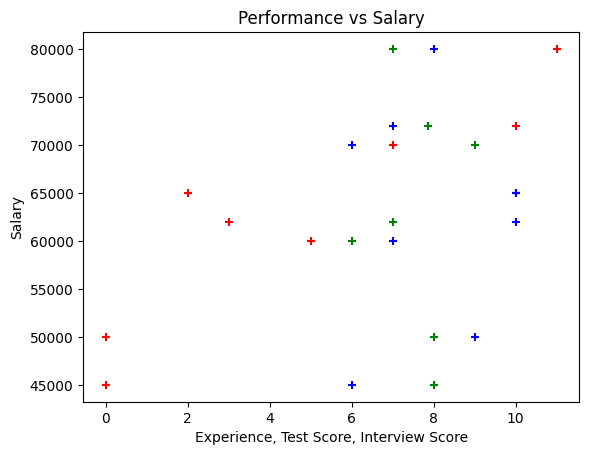

In [454]:
# Visualize the dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X["experience"], y, marker="+", color="red")
plt.scatter(X["test_score(out of 10)"], y, marker="+", color="green")
plt.scatter(X["interview_score(out of 10)"], y, marker="+", color="blue")
plt.xlabel("Experience, Test Score, Interview Score")
plt.ylabel("Salary")
plt.title("Performance vs Salary")
plt.show()

In [455]:
# Train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [456]:
# Print the report
from sklearn.metrics import r2_score

print(f"R2 score: {r2_score(y, model.predict(X))}")

R2 score: 0.9639958361860579


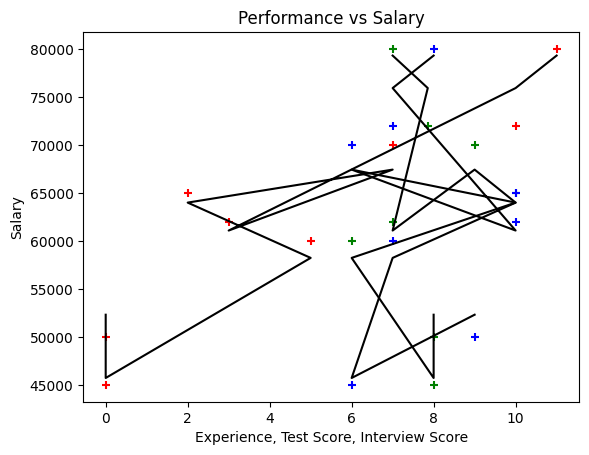

In [457]:
# Plot the model prediction
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X["experience"], y, marker="+", color="red")
plt.scatter(X["test_score(out of 10)"], y, marker="+", color="green")
plt.scatter(X["interview_score(out of 10)"], y, marker="+", color="blue")
plt.xlabel("Experience, Test Score, Interview Score")
plt.ylabel("Salary")
plt.title("Performance vs Salary")
plt.plot(X, model.predict(X), color="black")
plt.show()

In [458]:
# Print the model coeffients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients: [2827.63404314 1912.93803053 2196.9753141 ]
Intercept: 17237.330313727172


In [459]:
df = pd.read_csv("car driving risk analysis.csv")
df.head()

,speed,risk
0,200,95
1,90,20
2,300,98
3,110,60
4,240,72


In [460]:
# Print the shape, null values and sum of null values
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (15, 2)
Is Null Any: 
speed    False
risk     False
dtype: bool
Is Null Sum: 
speed    0
risk     0
dtype: int64


X_train shape: (12, 1)
X_test shape: (3, 1)
y_train shape: (12,)
y_test shape: (3,)
R2 score: 0.5931310028401033


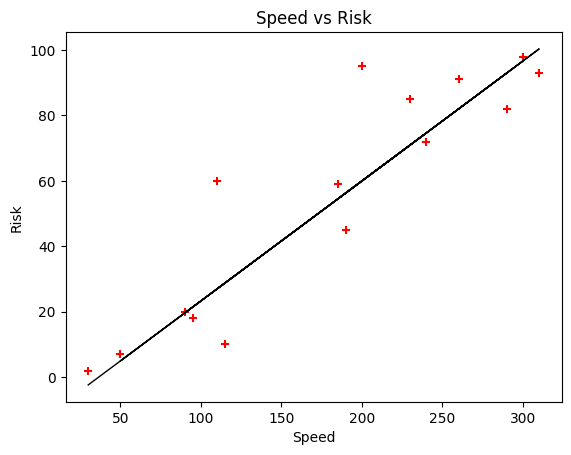

In [461]:
# Define X and y
X = df[["speed"]]
y = df["risk"]

# Split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Print the shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Print the report
from sklearn.metrics import r2_score

print(f"R2 score: {r2_score(y_test, model.predict(X_test))}")

# Plot the model prediction
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X["speed"], y, marker="+", color="red")
plt.xlabel("Speed")
plt.ylabel("Risk")
plt.title("Speed vs Risk")
plt.plot(X, model.predict(X), color="black", linewidth=1)
plt.show()

In [462]:
df = pd.read_csv("canada_per_capita_income.csv")
df.head()

,year,per capita income (US$),predicted
0,1970,3399.299037,-467.511725
1,1971,3768.297935,396.700725
2,1972,4251.175484,1260.913175
3,1973,4804.463248,2125.125625
4,1974,5576.514583,2989.338075


In [463]:
# Print the shape, null values and sum of null values
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (47, 3)
Is Null Any: 
year                       False
per capita income (US$)    False
predicted                  False
dtype: bool
Is Null Sum: 
year                       0
per capita income (US$)    0
predicted                  0
dtype: int64


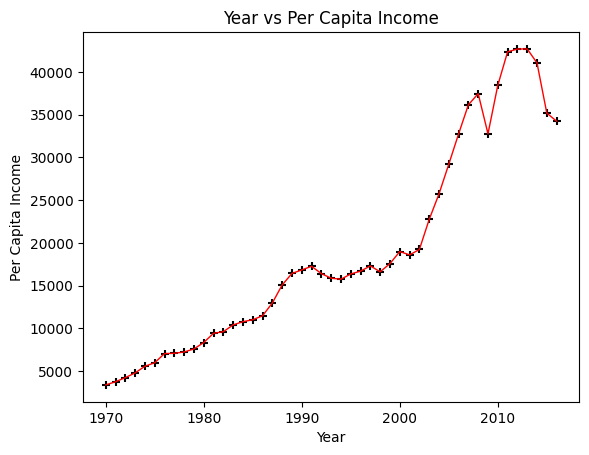

In [464]:
# Define the X and y
X = df[["year"]]
y = df["per capita income (US$)"]

# Visualize the dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X, y, marker="+", color="black")
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Year vs Per Capita Income")
plt.plot(X, y, color="red", linewidth=1)
plt.show()

X_train shape: (37, 1)
X_test shape: (10, 1)
y_train shape: (37,)
y_test shape: (10,)
R2 score: 0.8003604166786615


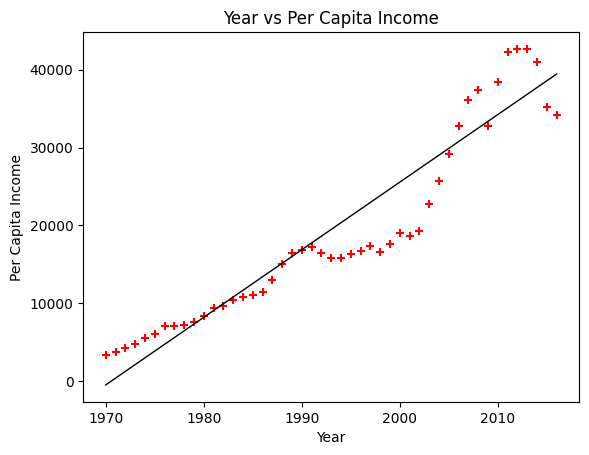

In [465]:
# Split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Print the shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Print the report
from sklearn.metrics import r2_score

print(f"R2 score: {r2_score(y_test, model.predict(X_test))}")

# Plot the model prediction
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X, y, marker="+", color="red")
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Year vs Per Capita Income")
plt.plot(X, model.predict(X), color="black", linewidth=1)
plt.show()

In [466]:
# Exercise
import pandas as pd


df = pd.read_csv("employee_salary_dataset.csv")
df.head()

,employee_id,age,experience_years,education_level,department,hours_per_week,performance_score,remote,join_date,salary
0,1126,34,10.7,Bachelor's,HR,42.0,7.7,No,2018-03-28,85895.43
1,1058,27,4.9,Bachelor's,Finance,38.0,8.7,Yes,2016-10-07,70728.27
2,1283,32,9.4,High School,Engineering,47.0,7.2,No,2020-10-03,77028.25
3,1067,30,3.5,Bachelor's,Engineering,40.0,8.8,yes,2015-09-08,74781.42
4,1115,35,15.8,PhD,Engineering,30.0,NaN,No,2020-03-03,105788.40


In [467]:
# Describe the dataset
print(f"Description: \n{df.describe()}")

Description: 
       employee_id         age  experience_years  hours_per_week  \
count   303.000000  303.000000        303.000000      291.000000   
mean   1150.660066   36.326733         12.339934       42.089347   
std      86.382217    8.133948          7.356069        4.853608   
min    1001.000000   21.000000          0.100000       30.000000   
25%    1076.500000   30.000000          5.950000       39.000000   
50%    1151.000000   37.000000         12.800000       42.000000   
75%    1224.500000   43.000000         18.800000       45.000000   
max    1300.000000   54.000000         24.800000       55.000000   

       performance_score         salary  
count         288.000000     303.000000  
mean            7.233333   91089.939436  
std             1.438253   23099.619142  
min             2.700000   17565.727500  
25%             6.275000   74456.515000  
50%             7.300000   90630.160000  
75%             8.200000  105681.915000  
max            10.000000  262710.3680

In [468]:
# Print the shape, null values and sum of null values
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (303, 10)
Is Null Any: 
employee_id          False
age                  False
experience_years     False
education_level      False
department            True
hours_per_week        True
performance_score     True
remote               False
join_date            False
salary               False
dtype: bool
Is Null Sum: 
employee_id           0
age                   0
experience_years      0
education_level       0
department            9
hours_per_week       12
performance_score    15
remote                0
join_date             0
salary                0
dtype: int64


In [469]:
# Print the data types
print(f"Data Types: \n{df.dtypes}")

Data Types: 
employee_id            int64
age                    int64
experience_years     float64
education_level       object
department            object
hours_per_week       float64
performance_score    float64
remote                object
join_date             object
salary               float64
dtype: object


In [470]:
# Print the unique values of the columns where data type is object
print(f"Unique Values where data type is object: \n{df.select_dtypes(include=['object']).nunique()}")

# Print the unique values of the columns where data type is not object
print(f"Unique Values where data type is not object: \n{df.select_dtypes(exclude=['object']).nunique()}")

Unique Values where data type is object: 
education_level      4
department           5
remote               4
join_date          289
dtype: int64
Unique Values where data type is not object: 
employee_id          300
age                   34
experience_years     179
hours_per_week        26
performance_score     60
salary               300
dtype: int64


In [471]:
# Print the each unique values of the columns where data type is object
for column in df.select_dtypes(include=["object"]).columns:
    print(f"Unique Values of {column}: \n{df[column].unique()}")
    print(f"Unique Values Count of {column}: \n{df[column].value_counts()}")
    print("\n")

Unique Values of education_level: 
["Bachelor's" 'High School' 'PhD' "Master's"]
Unique Values Count of education_level: 
education_level
Bachelor's     137
Master's        89
High School     50
PhD             27
Name: count, dtype: int64


Unique Values of department: 
['HR' 'Finance' 'Engineering' 'Sales' 'Marketing' nan]
Unique Values Count of department: 
department
Engineering    103
Sales           54
Finance         51
Marketing       47
HR              39
Name: count, dtype: int64


Unique Values of remote: 
['No' 'Yes' ' yes ' ' no ']
Unique Values Count of remote: 
remote
No       182
Yes      113
 no        5
 yes       3
Name: count, dtype: int64


Unique Values of join_date: 
['2018-03-28' '2016-10-07' '2020-10-03' '2015-09-08' '2020-03-03'
 '2023-06-10' '2023-07-15' '2023-09-19' '2016-08-14' '2024-04-02'
 '2019-05-23' '2017-11-30' '2017-04-18' '2020-05-15' '2019-10-04'
 '2024-01-08' '2024-03-09' '2022-04-24' '2018-04-13' '2015-06-20'
 '2022-02-17' '2016-01-06' '2017-09-3

In [472]:
# Clean inconsistent data
df["education_level"] = df["education_level"].str.strip().str.lower()
df["department"] = df["department"].str.strip().str.lower()
df["remote"] = df["remote"].str.strip().str.lower()

# Print the each unique values of the columns where data type is object
for column in df.select_dtypes(include=["object"]).columns:
    print(f"Unique Values of {column}: \n{df[column].unique()}")
    print(f"Unique Values Count of {column}: \n{df[column].value_counts()}")
    print("\n")

Unique Values of education_level: 
["bachelor's" 'high school' 'phd' "master's"]
Unique Values Count of education_level: 
education_level
bachelor's     137
master's        89
high school     50
phd             27
Name: count, dtype: int64


Unique Values of department: 
['hr' 'finance' 'engineering' 'sales' 'marketing' nan]
Unique Values Count of department: 
department
engineering    103
sales           54
finance         51
marketing       47
hr              39
Name: count, dtype: int64


Unique Values of remote: 
['no' 'yes']
Unique Values Count of remote: 
remote
no     187
yes    116
Name: count, dtype: int64


Unique Values of join_date: 
['2018-03-28' '2016-10-07' '2020-10-03' '2015-09-08' '2020-03-03'
 '2023-06-10' '2023-07-15' '2023-09-19' '2016-08-14' '2024-04-02'
 '2019-05-23' '2017-11-30' '2017-04-18' '2020-05-15' '2019-10-04'
 '2024-01-08' '2024-03-09' '2022-04-24' '2018-04-13' '2015-06-20'
 '2022-02-17' '2016-01-06' '2017-09-30' '2015-07-09' '2016-12-20'
 '2018-11-14' '2

In [473]:
# Feature engineering
df["join_date"] = pd.to_datetime(df["join_date"])

# Print the dataframe
df.head()

,employee_id,age,experience_years,education_level,department,hours_per_week,performance_score,remote,join_date,salary
0,1126,34,10.7,bachelor's,hr,42.0,7.7,no,2018-03-28,85895.43
1,1058,27,4.9,bachelor's,finance,38.0,8.7,yes,2016-10-07,70728.27
2,1283,32,9.4,high school,engineering,47.0,7.2,no,2020-10-03,77028.25
3,1067,30,3.5,bachelor's,engineering,40.0,8.8,yes,2015-09-08,74781.42
4,1115,35,15.8,phd,engineering,30.0,NaN,no,2020-03-03,105788.40


In [474]:
# Drop duplicate data
df.drop_duplicates(inplace=True)

# Drop rows where all values are missing
df.dropna(how="all", inplace=True)

# Drop NaN values where the data type is object
df.dropna(subset=["education_level", "department", "remote"], inplace=True)

# Print the shape, null values and sum of null values
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (291, 10)
Is Null Any: 
employee_id          False
age                  False
experience_years     False
education_level      False
department           False
hours_per_week        True
performance_score     True
remote               False
join_date            False
salary               False
dtype: bool
Is Null Sum: 
employee_id           0
age                   0
experience_years      0
education_level       0
department            0
hours_per_week       12
performance_score    14
remote                0
join_date             0
salary                0
dtype: int64


In [475]:
# Fill the NaN values
df["hours_per_week"] = df["hours_per_week"].fillna(df["hours_per_week"].mean())
df["performance_score"] = df["performance_score"].fillna(df["performance_score"].mean())

# Print the shape, null values and sum of null values
print(f"Shape: {df.shape}")
print(f"Is Null Any: \n{df.isnull().any()}")
print(f"Is Null Sum: \n{df.isnull().sum()}")

Shape: (291, 10)
Is Null Any: 
employee_id          False
age                  False
experience_years     False
education_level      False
department           False
hours_per_week       False
performance_score    False
remote               False
join_date            False
salary               False
dtype: bool
Is Null Sum: 
employee_id          0
age                  0
experience_years     0
education_level      0
department           0
hours_per_week       0
performance_score    0
remote               0
join_date            0
salary               0
dtype: int64


In [476]:
# Print the each unique values of the columns where data type is object
for column in df.select_dtypes(include=["object"]).columns:
    print(f"Unique Values of {column}: \n{df[column].unique()}")
    print(f"Unique Values Count of {column}: \n{df[column].value_counts()}")
    print("\n")

Unique Values of education_level: 
["bachelor's" 'high school' 'phd' "master's"]
Unique Values Count of education_level: 
education_level
bachelor's     134
master's        84
high school     47
phd             26
Name: count, dtype: int64


Unique Values of department: 
['hr' 'finance' 'engineering' 'sales' 'marketing']
Unique Values Count of department: 
department
engineering    102
sales           54
finance         50
marketing       47
hr              38
Name: count, dtype: int64


Unique Values of remote: 
['no' 'yes']
Unique Values Count of remote: 
remote
no     180
yes    111
Name: count, dtype: int64




In [477]:
# Get dummies for categorical data
df_encoded = pd.get_dummies(
    df, 
    columns=["education_level", "department", "remote"],
    prefix=["education_level", "department", "remote"],
    drop_first=True
)

# Print the dataframe
df_encoded.head()

,employee_id,age,experience_years,hours_per_week,performance_score,join_date,salary,education_level_high school,education_level_master's,education_level_phd,department_finance,department_hr,department_marketing,department_sales,remote_yes
0,1126,34,10.7,42.0,7.700000,2018-03-28,85895.43,False,False,False,False,True,False,False,False
1,1058,27,4.9,38.0,8.700000,2016-10-07,70728.27,False,False,False,True,False,False,False,True
2,1283,32,9.4,47.0,7.200000,2020-10-03,77028.25,True,False,False,False,False,False,False,False
3,1067,30,3.5,40.0,8.800000,2015-09-08,74781.42,False,False,False,False,False,False,False,True
4,1115,35,15.8,30.0,7.232491,2020-03-03,105788.40,False,False,True,False,False,False,False,False


In [478]:
# Define X and y
X = df_encoded.drop(["salary", "employee_id", "age", "join_date"], axis=1)
y = df_encoded["salary"]

# Print the shape of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("\n")

Shape of X: (291, 11)
Shape of y: (291,)




In [479]:
# Split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Print the shape of X_train and X_test
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("\n")

X_train shape: (232, 11)
X_test shape: (59, 11)




In [480]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# Print the model coeffients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print("\n")

Coefficients: [ 1986.26361066    85.17758466   714.14878892 -9995.90132338
  4272.50822658 20900.36174792 -7779.67168926 -1048.63611954
 -9126.81524699  -629.48399844  -739.21487572]
Intercept: 60259.76349993741




In [481]:
# Print the report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


print(f"R2 Score: {r2_score(y_test, model.predict(X_test))}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, model.predict(X_test))}")
print(f"Mean Squared Error: {mean_squared_error(y_test, model.predict(X_test))}")

R2 Score: 0.8744872024495063
Mean Absolute Error: 5042.7712986512415
Mean Squared Error: 41933964.99803344


In [482]:
# Use of OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop(["salary", "employee_id", "age", "join_date"], axis=1)
y = df["salary"]

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Apply OneHotEncoder
categorical_columns = ["education_level", "department", "remote"]
numeric_columns = ["experience_years", "hours_per_week", "performance_score"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns),
    ], 
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Create the model
model = LinearRegression()

# Fit the model
model.fit(X_train_encoded, y_train)

# Print the report
print(f"R2 Score: {r2_score(y_test, model.predict(X_test_encoded))}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, model.predict(X_test_encoded))}")
print(f"Mean Squared Error: {mean_squared_error(y_test, model.predict(X_test_encoded))}")

R2 Score: 0.8744872024495068
Mean Absolute Error: 5042.77129865123
Mean Squared Error: 41933964.99803326


In [483]:
df

,employee_id,age,experience_years,education_level,department,hours_per_week,performance_score,remote,join_date,salary
0,1126,34,10.7,bachelor's,hr,42.0,7.700000,no,2018-03-28,85895.43
1,1058,27,4.9,bachelor's,finance,38.0,8.700000,yes,2016-10-07,70728.27
2,1283,32,9.4,high school,engineering,47.0,7.200000,no,2020-10-03,77028.25
3,1067,30,3.5,bachelor's,engineering,40.0,8.800000,yes,2015-09-08,74781.42
4,1115,35,15.8,phd,engineering,30.0,7.232491,no,2020-03-03,105788.40
...,...,...,...,...,...,...,...,...,...,...
297,1104,36,12.7,master's,finance,34.0,6.200000,no,2015-09-22,92031.33
298,1212,41,17.3,phd,finance,42.0,6.900000,yes,2019-03-22,111359.27
299,1068,46,20.1,master's,engineering,44.0,5.800000,no,2018-05-31,114488.99
301,1197,45,18.1,bachelor's,engineering,39.0,7.900000,no,2022-08-22,107454.54


In [484]:
# Use of OrdinalEncoder and OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder


# Create the OrdinalEncoder
education_order = ["bachelor's", "high school", "master's", "phd"]
ordinal_encoder = OrdinalEncoder(categories=[education_order])

df["education_level"] = ordinal_encoder.fit_transform(df[["education_level"]])

# Create the OneHotEncoder
one_hot_encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

one_hot_encoded_array = one_hot_encoder.fit_transform(df[["department", "remote"]])

# Let the encoder generate the correct column names instead of hardcoding them
encoded_cols = one_hot_encoder.get_feature_names_out(["department", "remote"])

one_hot_encoded_df = pd.DataFrame(
    one_hot_encoded_array,
    columns=encoded_cols,
    index=df.index  # keeps row alignment correct for the concat below
)

# Concatenate the encoded columns with the original DataFrame
df_encoded = pd.concat(
    [df.drop(columns=["department", "remote"]), one_hot_encoded_df],
    axis=1
)

df_encoded.head()

,employee_id,age,experience_years,education_level,hours_per_week,performance_score,join_date,salary,department_finance,department_hr,department_marketing,department_sales,remote_yes
0,1126,34,10.7,0.0,42.0,7.700000,2018-03-28,85895.43,0.0,1.0,0.0,0.0,0.0
1,1058,27,4.9,0.0,38.0,8.700000,2016-10-07,70728.27,1.0,0.0,0.0,0.0,1.0
2,1283,32,9.4,1.0,47.0,7.200000,2020-10-03,77028.25,0.0,0.0,0.0,0.0,0.0
3,1067,30,3.5,0.0,40.0,8.800000,2015-09-08,74781.42,0.0,0.0,0.0,0.0,1.0
4,1115,35,15.8,3.0,30.0,7.232491,2020-03-03,105788.40,0.0,0.0,0.0,0.0,0.0


In [485]:
# Define X and y
X = df_encoded.drop(["salary", "employee_id", "age", "join_date"], axis=1)
y = df_encoded["salary"]

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

# Create the model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# Print the report
print(f"R2 Score: {r2_score(y_test, model.predict(X_test))}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, model.predict(X_test))}")
print(f"Mean Squared Error: {mean_squared_error(y_test, model.predict(X_test))}")

R2 Score: 0.825773463588718
Mean Absolute Error: 5917.398085781163
Mean Squared Error: 58209279.23035177
